# Week 6: Regression

This notebook applies a baseline regression model to predict emotional intensity from extracted audio features.

In [ ]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# Resolve project root from notebook location
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "SER_Project").exists():
    PROJECT_ROOT = NOTEBOOK_DIR / "SER_Project"
elif NOTEBOOK_DIR.name == "notebooks" and (NOTEBOOK_DIR.parent / "pipeline").exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
FEATURES_CSV = DATA_DIR / "features.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FEATURES_CSV exists: {FEATURES_CSV.exists()}")

PROJECT_ROOT: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project
FEATURES_CSV exists: True


In [3]:
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f"Missing {FEATURES_CSV}. Run the feature extraction pipeline first (notebook 01 or CLI)."
    )

df = pd.read_csv(FEATURES_CSV)
print(df.shape)
df.head(3)

(1440, 384)


,filepath,filename,modality_code,vocal_channel_code,emotion_code,intensity_code,statement_code,repetition,actor_id,modality,...,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,duration_seconds,signal_abs_mean
0,C:\Users\wblut\Documents\My Projects\Python\CS...,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,audio-only,...,0.002120,0.003391,7416.297748,4428.027505,5551.291828,1966.670942,13285.735887,7873.634242,3.303292,0.001663
1,C:\Users\wblut\Documents\My Projects\Python\CS...,03-01-01-01-01-01-02.wav,3,1,1,1,1,1,2,audio-only,...,0.003345,0.005519,4876.754825,3813.320523,4398.780650,2532.902086,9352.456012,7619.598807,3.636958,0.002492
2,C:\Users\wblut\Documents\My Projects\Python\CS...,03-01-01-01-01-01-03.wav,3,1,1,1,1,1,3,audio-only,...,0.003757,0.006070,4968.033485,3859.034171,4458.211223,2472.907411,9552.051084,7517.358922,3.436771,0.002893


In [4]:
# Target for regression: intensity_code (1=normal, 2=strong)
target_col = "intensity_code"
if target_col not in df.columns:
    raise KeyError(f"Expected target column '{target_col}' in features.csv")

drop_cols = [
    "filepath", "filename",
    "modality", "vocal_channel", "emotion", "intensity", "statement",
    "modality_code", "vocal_channel_code", "emotion_code", "statement_code",
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols + [target_col]
]

X = df[feature_cols].copy()
y = df[target_col].astype(float).copy()

print(f"Features: {X.shape[1]}")
print(f"Rows: {X.shape[0]}")
print(y.value_counts().sort_index())

Features: 372
Rows: 1440
intensity_code
1.0    768
2.0    672
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df["emotion"] if "emotion" in df.columns else None,
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, feature_cols)],
    remainder="drop",
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression()),
], memory=None)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:  {r2:.4f}")

MSE: 0.2035
MAE: 0.3557
R²:  0.1861


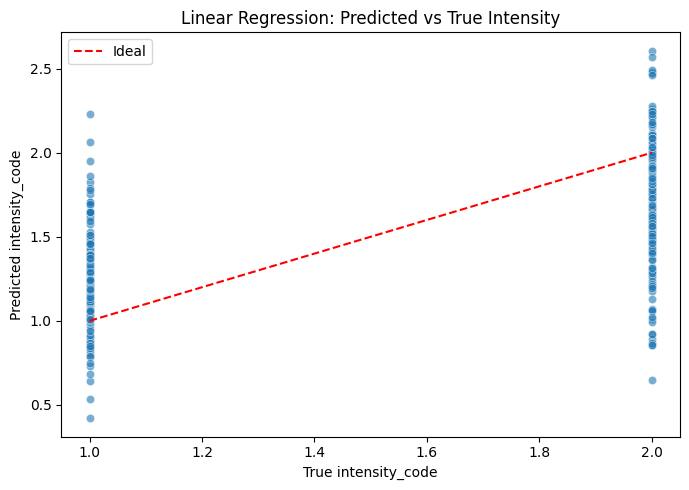

,y_true,y_pred
0,1.0,1.381174
1,2.0,1.274109
2,2.0,1.892225
3,1.0,1.949994
4,1.0,0.872931


In [6]:
results = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=results, x="y_true", y="y_pred", alpha=0.6)
plt.plot([1, 2], [1, 2], color="red", linestyle="--", label="Ideal")
plt.title("Linear Regression: Predicted vs True Intensity")
plt.xlabel("True intensity_code")
plt.ylabel("Predicted intensity_code")
plt.legend()
plt.tight_layout()
plt.show()

results.head()